In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math


from RK4 import * 

from SWESBP_2d import * 

In [2]:
import timeit

# #plt.switch_backend("TkAgg")          # plots in external window
# plt.switch_backend("nbagg") 

In [3]:
p1 = SWE_SBP()
p1.acoustic_rate

print(24*60*60*10)

864000


In [4]:
# Initializations
L = 4e5        # length of the domain (km)
t = 0.0          # initial time
tend = 10000#.# final time

nx = 101
ny = 101 #641#1281#2561 #3201#1601#3201      # grid points in x                                                                                                                       
dx = L/(nx-1)
dy = L/(ny-1)# grid increment in x
    # velocity (km/s) (can be an array)                                                                                                             
iplot =20      # snapshot frequency
rho = 1#2.6702     # density [g/cm^3]
K =  2.2 #rho*cs**2 

g = 9.81
H = 10

Ubar= 0# -0.3*np.sqrt(g*H)
Vbar = Ubar
#cs = np.sqrt(K/rho)# shear modulus [GPa]
#Zs = rho * cs
  # shear impedance 

order =4# order of accuracy
# uy =np.zeros((nx,ny))
# vx = np.zeros((nx,ny))

#Initialize the domain

x = np.zeros((nx, ny))
y = np.zeros((nx, ny))
              
p = np.zeros((nx, ny))    

# Initial particle velocity perturbation and discretize the domain
for i in range(0, nx):
    for j in range(0, ny):
        #F[i, j,0] = np.exp(-np.log(2)*(((i-isx)*dx)**2/(sigma) + ((j-isy)*dy)**2/(sigma)))
        x[i, j] = i*dx
        y[i,j] = j*dy



# Time stepping parameters
cfl = 0.1      # CFL number
dt = (cfl/(50+ np.sqrt(g*H)))*dx                  # Time step
nt = int(round(tend/dt))          # number of time steps
n = 0                             # counter
print(nt)
# Boundary condition reflection coefficients 
# r0 = 0                          # r=0:absorbing, r=1:free-surface, r=-1: clamped 
# r1 = 0                            # r=0:absorbing, r=1:free-surface, r=-1: clamped

# # penalty parameters
# tau_11 = 1 #-1  #\tau_{11}  this is for v0
# tau_12 = 1   #\tau_{1N}}     thisis for p0 #switch tau_11 and tau_22 to -1 if we are using energy flux cons.
# tau_21 = 1    #\tau_{21}    this is for vn
# tau_22 = 1     #\tau_{2N} this is for pn

# Initialize: particle velocity (v); and shear stress (s)
u = np.zeros((nx,ny))
v = np.zeros((nx,ny))
p = np.zeros((nx,ny))

U = np.zeros((nx,ny))
V = np.zeros((nx,ny))
P = np.zeros((nx,ny))

U_t = np.zeros((nx,ny))
V_t = np.zeros((nx,ny))
P_t = np.zeros((nx,ny))

U_x =np.zeros((nx,ny))
V_x = np.zeros((nx,ny))
P_x = np.zeros((nx,ny))

                                

# Difference between analyticla and numerical solutions
EV = [0]                                 # initialize errors in V (velocity)
EU = [0]                                 # initialize errors in U (stress)
T = [0]   
ERROR = [0]          

1498


In [5]:
from dpsbp_operators_periodic import dxd_m_DP_periodic, dxd_p_DP_periodic, dyd_m_DP_periodic, dyd_p_DP_periodic
from sbp_operators_periodic import dxd_m_SBP_periodic, dyd_m_SBP_periodic
t=0   # initial time



  # forcing function, forcing = 1,  and no forcing function, forcing = 0

# type of initial data: Gaussian or Sinusoidal
type_0 = 'KH_Peixoto'
#type_0 = 'Dam_Brea'
#type_0 = 'Sinusoidal'
#plt.contourf(x,y,u)
if type_0 in ('Sinusoidal'):
            forcing = 1.0  # we must use forcing for Sinusoidal initial condition

# L2-norm normalizer

p1.mms(u, v,p, U_t, V_t, P_t,U_x, V_x,P_t,x, y, t+dt, Ubar,Vbar,type_0 ,nx,ny,dx,dy,order)
A =  (np.linalg.norm(v)) 
B =  (np.linalg.norm(p))



# Loop through time and evolve the wave-fields using ADER time-stepping scheme of N+1 order of accuracy
start = timeit.default_timer()
#type_0 = 'Sinusoidal'
# Generate initial conditions
p1.mms(u, v,p, U_t, V_t, P_t,U_x, V_x,P_t,x, y, t+dt, Ubar,Vbar,type_0 ,nx,ny,dx,dy,order)



f = 2 * 7.292e-5
uy =np.zeros((nx,ny))
vx = np.zeros((nx,ny))

# dyd_m_SBP_periodic(uy, u,ny,dy,order)
# dxd_m_SBP_periodic(vx,v, nx,dx,order)


# vort = np.abs((uy - vx +f ) )
# # #plt.colorbar()


# plt.pcolormesh(x,y,u)
# plt.colorbar()

# v = 0*v +50
# u = 0*u+50
#plt.colorbar()

for t in np.arange(0.0, (tend+dt),dt):
    n = n+1
    
    #delta = (y[-1,0]-y[0,0])
    #L = 10
#fd_type 

# SBP, DP, DRP (non-periodic) , SBP_periodic, DP_periodic, DRP_periodic (periodic)
    
    # compute numerical solution 
    acoustic_RK4(p1,u,v, p, u, v, p, rho, K, nx,ny, dx,dy, order,x, y, t, dt,
                     type_0,Ubar,Vbar,H, g,flux_type='nonlinear',vorticity = 'true')
    #def acoustic_RK4(self,ru, rv, rp,u, v, p, rho, K, nx,ny, dx,dy, order, x, y, t, dt, type_0, Ubar,Vbar, H, g):
 # Analytical solution
    p1.mms(U, V,P, U_t, V_t, P_t,U_x, V_x,P_t,x, y, (t+dt), Ubar,Vbar,type_0 ,nx,ny,dx,dy,order)

    #ms(self,U,V, P, U_t, V_t, P_t, V_x, P_x,x, y, t, Ubar,Vbar,type_0,nx,ny):
    #def acoustic_RK4(self,ru, rv, rp,u, v, p, rho, K, nx,ny, dx,dy, order, x, y, t, dt, type_0, U ,V,H,g,fd_type):
    # compute error and append to the error array
    EU.append(np.linalg.norm(U-v)/A)
    EV.append(np.linalg.norm(V-p)/B)
    #print(energy_t)
    error =  ((p*u**2 + g * p**2).sum())
    ERROR.append(error)




dyd_m_SBP_periodic(uy, u,ny,dy,order)
dxd_m_SBP_periodic(vx,v, nx,dx,order)


vort = ((vx - uy +f ) )        

print(ERROR)
#plt.colorbar()
# # plt.show()
plt.pcolormesh(x/1e3,y/1e3,u,cmap = 'jet')
plt.colorbar()
plt.show()

# # plt.show()
# plt.pcolormesh(x,y,p+H)
# plt.colorbar()
plt.show()
plt.ioff()
# Simulation end time
stop = timeit.default_timer()
print('total simulation time = ', stop - start)                   # print the time required for simulation
print('spatial order | of accuracy = ', order)                                  # print the polynomial degree used
print('number of grid points = ', nx)                     # print the degree of freedom
print('maximum relative error in particle velocity = ', max(EU))  # max. relative error in particle velocity
print('maximum relative error in stress = ', max(EV))             # max. relative error in stress

-3.511240481065685e-07


/var/folders/y8/yypvc6yd355fxc2039gq0h2c0000gn/T/ipykernel_7601/1582178877.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  EU.append(np.linalg.norm(U-v)/A)


5.0454487379109695e-05
0.0001012927690427687
0.0001522565053920602
0.00020343931383076655
0.0002549362654660727
0.0003068445260813002
0.0003592640255131459
0.00041229816366154755
0.00046605456123082427
0.0005206458628572113
0.0005761905993750337
0.0006328141144807823
0.0006906495588915336
0.000749838952289936
0.0008105343101234143
0.0008728988292144577
0.0009371081241556716
0.0010033515073190208
0.001071833311688335
0.0011427742716096582
0.0012164130075721276
0.0012930077148616
0.0013728382420476548
0.0014562088753184257
0.0015434523311176067
0.0016349357134604115
0.0017310695190654963
0.0018323211649662172
0.001939234935506214
0.0020524606191715247
0.002172793277269361
0.0023012262886174055
0.0024390186109628995
0.0025877744138783965
0.0027495278592271116
0.0029268163743006834
0.003122710232447506
0.003340741871640549
0.0035846417824874598
0.003857736175695889
0.004161797860751648
0.004495092473313247
0.004849433866681476
0.005206595537025273
0.005536354440086196
0.005803895292882047


/Users/justinhew/Downloads/DPSBP 3/current_DPSBP_code/SWE_2d/SWESBP_2d.py:260: RuntimeWarning: overflow encountered in multiply
  flux_hx = u*(h)
/Users/justinhew/Downloads/DPSBP 3/current_DPSBP_code/SWE_2d/SWESBP_2d.py:261: RuntimeWarning: overflow encountered in multiply
  flux_hy = v*(h)  #h
/Users/justinhew/Downloads/DPSBP 3/current_DPSBP_code/SWE_2d/SWESBP_2d.py:262: RuntimeWarning: overflow encountered in square
  flux_u =  (u**2+v**2)/2 + g*(h) ##Ubar*v + g*h
/Users/justinhew/Downloads/DPSBP 3/current_DPSBP_code/SWE_2d/dpsbp_operators_periodic.py:110: RuntimeWarning: invalid value encountered in add
  ux[i,:] = (-5/60*u[(i-3)%m,:]  +    1/2*u[(i-2)%m,:]   -3/2*u[(i-1)%m,:]  +   5/6*u[i%m,:]    + 1/4*u[(i+1)%m,:])
/Users/justinhew/Downloads/DPSBP 3/current_DPSBP_code/SWE_2d/dpsbp_operators_periodic.py:258: RuntimeWarning: invalid value encountered in add
  ux[:,i] = (-5/60*u[:,(i-3)%m]  +    1/2*u[:,(i-2)%m]   -3/2*u[:,(i-1)%m]  +   5/6*u[:,i%m]    + 1/4*u[:,(i+1)%m])
/Users/just

nan


/Users/justinhew/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


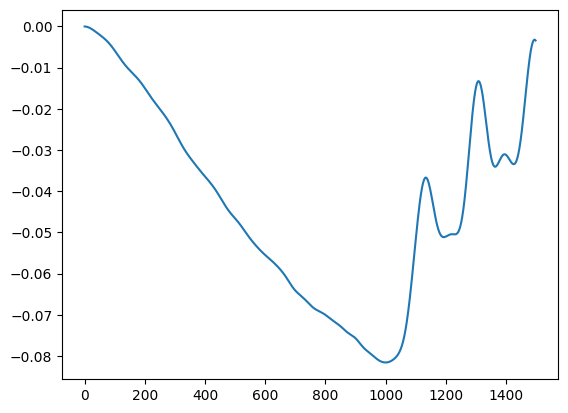

In [ ]:
energy_array = np.array(ERROR[1:])

error = (energy_array - energy_array[0])/energy_array[0]


plt.plot(error)
plt.show()

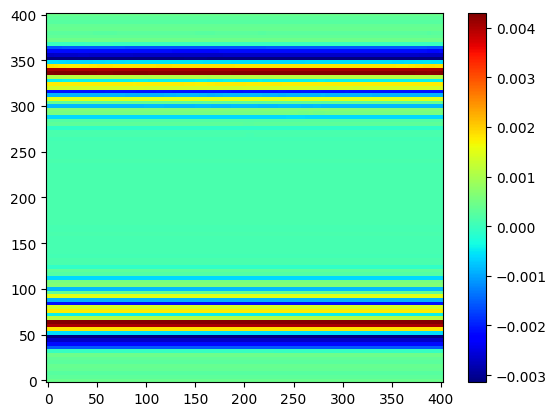

In [ ]:
plt.pcolormesh(x/1e3,y/1e3,vort,cmap = 'jet')
plt.colorbar()
plt.show()